--- Model Results ---
OLS Test MSE: 794.01
LASSO Test MSE: 800.80
LASSO R-Squared: 0.9190


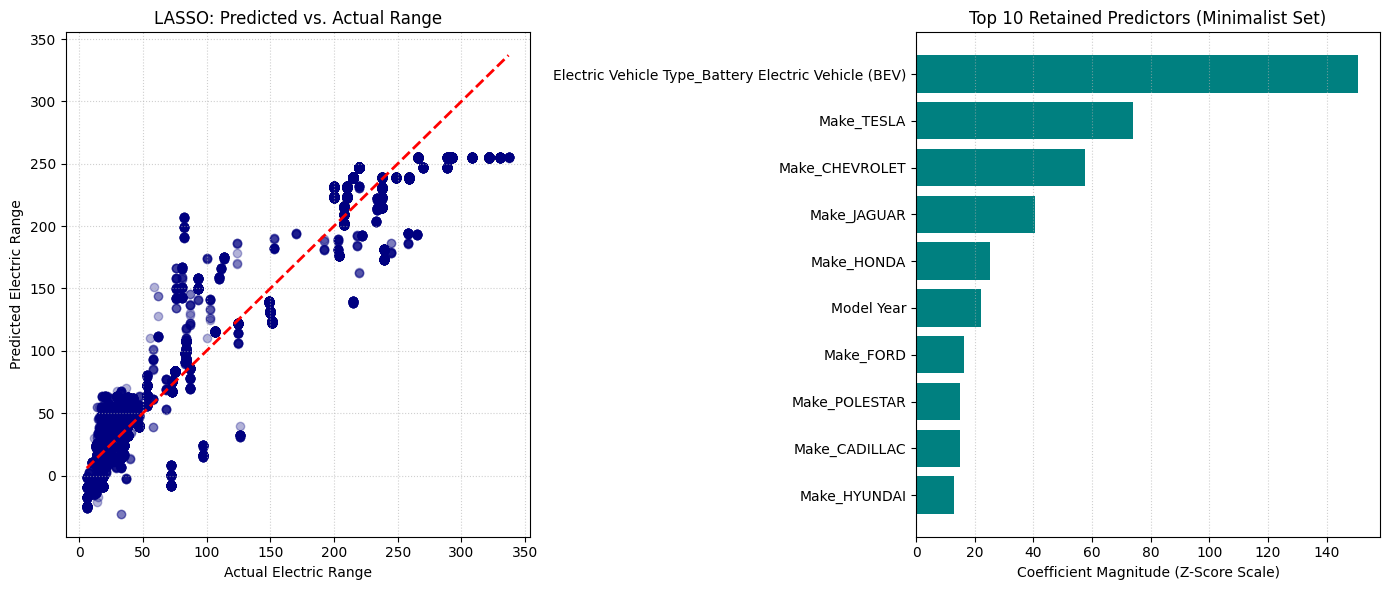


--- LASSO Dimensionality Reduction Summary ---
Features zeroed out as noise: 85
Features retained in minimalist set: 27


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- 1. DATA WRANGLING ---
# Ensure your CSV file is named exactly this and is in the same folder
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

# Defining features based on standard dataset headers
features = [
    'Make', 
    'Model Year', 
    'Electric Vehicle Type', 
    'Base MSRP', 
    'Electric Utility', 
    'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
]
target = 'Electric Range'

# Cleaning: Drop missing values and filter for vehicles with range data > 0
df_clean = df.dropna(subset=features + [target]).copy()
df_clean = df_clean[df_clean[target] > 0]

# --- 2. PREPROCESSING PIPELINE ---
num_cols = ['Model Year', 'Base MSRP']
cat_cols = [
    'Make', 
    'Electric Vehicle Type', 
    'Electric Utility', 
    'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
]

X = df_clean[features]
y = df_clean[target]

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transformer for Z-score scaling (numerical) and One-Hot Encoding (categorical)
preprocessor = ColumnTransformer(transformers=[
    ('zscore', StandardScaler(), num_cols),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# --- 3. MODELING: OLS vs. LASSO ---
# LASSO will handle the dimensionality reduction by zeroing out "noise" variables
ols = Pipeline([('prep', preprocessor), ('reg', LinearRegression())])
lasso = Pipeline([('prep', preprocessor), ('reg', LassoCV(cv=5))])

ols.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# --- 4. PERFORMANCE EVALUATION ---
ols_preds = ols.predict(X_test)
lasso_preds = lasso.predict(X_test)

print(f"--- Model Results ---")
print(f"OLS Test MSE: {mean_squared_error(y_test, ols_preds):.2f}")
print(f"LASSO Test MSE: {mean_squared_error(y_test, lasso_preds):.2f}")
print(f"LASSO R-Squared: {r2_score(y_test, lasso_preds):.4f}")

# --- 5. VISUALIZATION (Pure Matplotlib) ---
plt.figure(figsize=(14, 6))

# Plot 1: Predicted vs. Actual
plt.subplot(1, 2, 1)
plt.scatter(y_test, lasso_preds, alpha=0.3, color='navy')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.title('LASSO: Predicted vs. Actual Range', fontsize=12)
plt.xlabel('Actual Electric Range')
plt.ylabel('Predicted Electric Range')
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Top Retained Predictors
ohe_names = lasso.named_steps['prep'].named_transformers_['ohe'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(ohe_names)
coefs = lasso.named_steps['reg'].coef_

coef_df = pd.DataFrame({'Variable': all_feature_names, 'Weight': coefs})
important_coefs = coef_df[coef_df['Weight'] != 0].sort_values(by='Weight')

plt.subplot(1, 2, 2)
plt.barh(important_coefs['Variable'].tail(10), important_coefs['Weight'].tail(10), color='teal')
plt.title('Top 10 Retained Predictors (Minimalist Set)', fontsize=12)
plt.xlabel('Coefficient Magnitude (Z-Score Scale)')
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- 6. CPSC 392 INSIGHT ---
dropped_count = len(coefs) - len(important_coefs)
print(f"\n--- LASSO Dimensionality Reduction Summary ---")
print(f"Features zeroed out as noise: {dropped_count}")
print(f"Features retained in minimalist set: {len(important_coefs)}")

/var/folders/51/vwl3sq456q1b4fbvhkw4gpcw0000gn/T/ipykernel_26129/1232502166.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(msrp_data, labels=[f'Persona {i}' for i in range(k)])


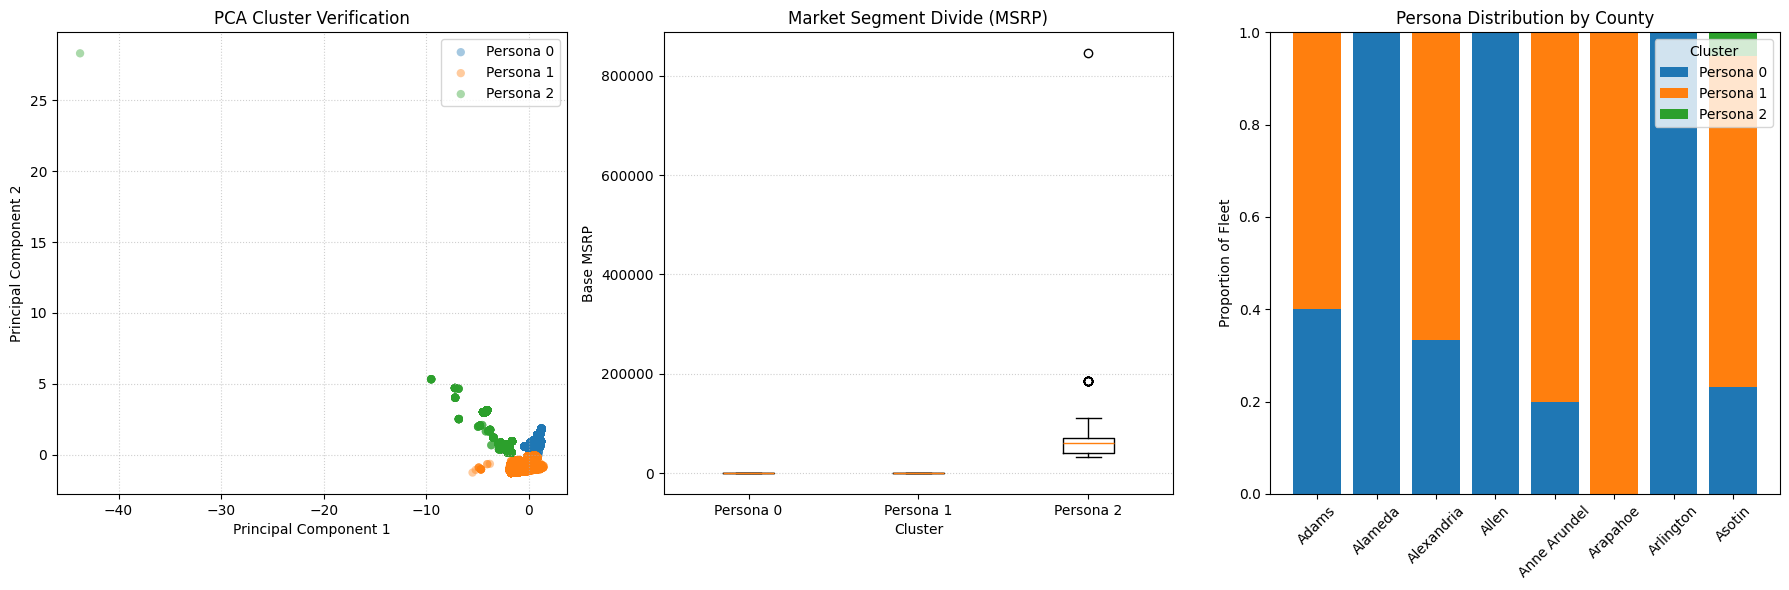

--- Cluster Centroids (Original Averages) ---
    Model Year  Electric Range     Base MSRP
0  2018.560408      232.815081  1.218723e-10
1  2017.571971       46.008368  1.723492e-10
2  2015.558995      123.475175  5.709393e+04


In [10]:
#QUESTION 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats

# --- 1. DATA WRANGLING & CLEANING ---
# Ensure your local file is named 'Electric_Vehicle_Population_Data.csv'
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

# Defining clustering variables (Numerical) and context variables (Categorical)
cluster_vars = ['Model Year', 'Electric Range', 'Base MSRP']
context_vars = ['Electric Utility', 'County']

# Cleaning: Drop rows with missing values in key columns
df_clean = df.dropna(subset=cluster_vars + context_vars).copy()

# Filter: Focus on vehicles with established range data (> 0)
df_clean = df_clean[df_clean['Electric Range'] > 0]

# --- 2. STANDARDIZATION ---
# Standardizing the features using Z-score (Essential for K-Means distance calculations)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[cluster_vars])

# --- 3. MODELING: K-MEANS & GMM ---
# K-Means for hard-assignment (Identifying distinct personas)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# GMM for soft-assignment cross-check (Verifying robustness)
gmm = GaussianMixture(n_components=k, random_state=42)
df_clean['GMM_Cluster'] = gmm.fit_predict(X_scaled)

# --- 4. DIMENSIONALITY REDUCTION (PCA) ---
# Compressing the 3 variables into 2 dimensions for visual verification
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_clean['PCA1'] = X_pca[:, 0]
df_clean['PCA2'] = X_pca[:, 1]

# --- 5. VISUALIZATION (Pure Matplotlib) ---
plt.figure(figsize=(18, 6))

# Plot 1: PCA Cluster Plot (Mathematical Verification)
plt.subplot(1, 3, 1)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Distinct colors for personas
for i in range(k):
    subset = df_clean[df_clean['Cluster'] == i]
    plt.scatter(subset['PCA1'], subset['PCA2'], c=colors[i], label=f'Persona {i}', alpha=0.4, edgecolors='none')
plt.title('PCA Cluster Verification', fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Cluster Boxplot (Luxury vs. Utility Divide)
plt.subplot(1, 3, 2)
# Creating a list of MSRP arrays for each cluster to plot
msrp_data = [df_clean[df_clean['Cluster'] == i]['Base MSRP'] for i in range(k)]
plt.boxplot(msrp_data, labels=[f'Persona {i}' for i in range(k)])
plt.title('Market Segment Divide (MSRP)', fontsize=12)
plt.xlabel('Cluster')
plt.ylabel('Base MSRP')
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Plot 3: Cluster Bar Chart (Spatial Distribution by County)
plt.subplot(1, 3, 3)
# Grouping by County and Cluster, then normalizing for a 100% stacked bar chart
county_counts = df_clean.groupby(['County', 'Cluster']).size().unstack().fillna(0)
# Showing top 8 counties for readability
top_counties = county_counts.head(8)
# Normalizing to get proportions
top_counties_pct = top_counties.div(top_counties.sum(axis=1), axis=0)

# Plotting the stacked bar chart
bottom = np.zeros(len(top_counties_pct))
for i in range(k):
    plt.bar(top_counties_pct.index, top_counties_pct[i], bottom=bottom, label=f'Persona {i}', color=colors[i])
    bottom += top_counties_pct[i]

plt.title('Persona Distribution by County', fontsize=12)
plt.xticks(rotation=45)
plt.ylabel('Proportion of Fleet')
plt.legend(title='Cluster', loc='upper right')

plt.tight_layout()
plt.show()

# --- 6. SUMMARY INSIGHT ---
print("--- Cluster Centroids (Original Averages) ---")
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=cluster_vars)
print(centroid_df)

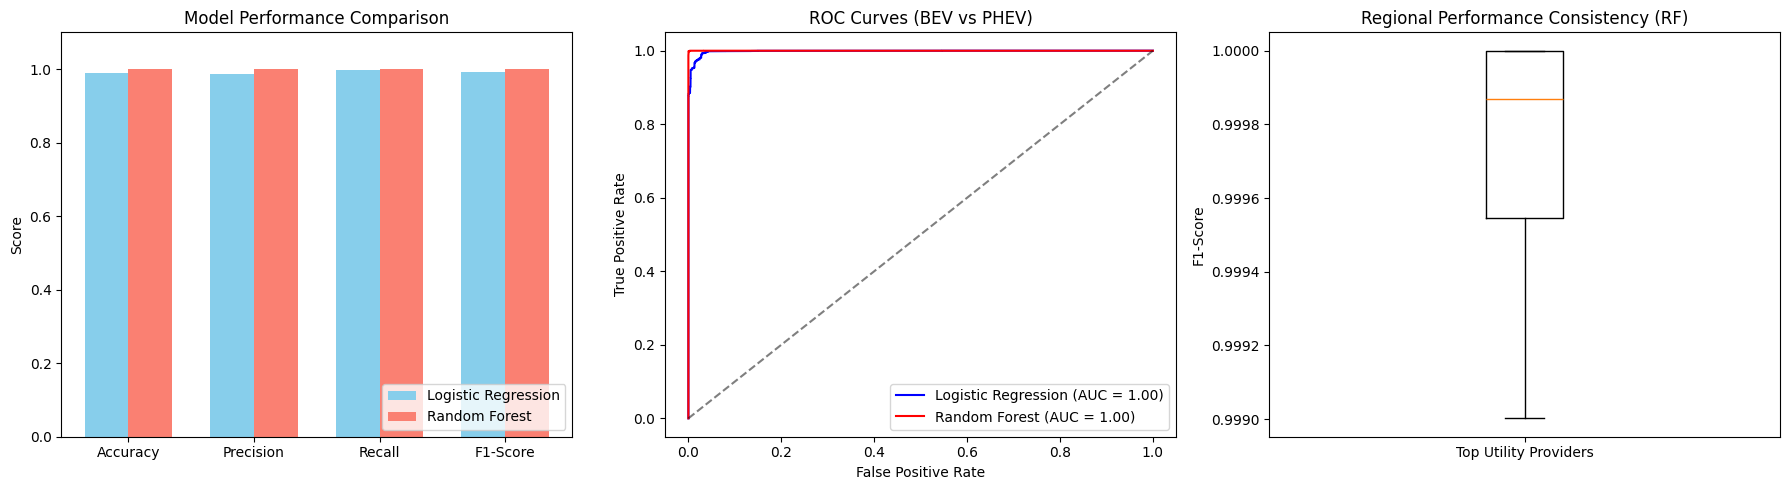

Logistic Regression Accuracy: 0.9882
Random Forest Accuracy: 0.9989


In [11]:
#QUESTION 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_curve, auc)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- 1. DATA WRANGLING & CLEANING ---
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

# Defining the specific variables from your research question
# Target: Electric Vehicle Type (BEV vs PHEV)
target = 'Electric Vehicle Type'
num_features = ['Model Year', 'Base MSRP', 'Electric Range']
cat_features = ['County', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Utility']

# Cleaning: Drop rows with missing values in target or key predictors
df_clean = df.dropna(subset=[target] + num_features + cat_features).copy()

# Remove extreme outliers in MSRP and Range (using 99th percentile)
df_clean = df_clean[df_clean['Base MSRP'] < df_clean['Base MSRP'].quantile(0.99)]
df_clean = df_clean[df_clean['Electric Range'] < df_clean['Electric Range'].quantile(0.99)]

# --- 2. PREPROCESSING ---
X = df_clean[num_features + cat_features]
y = df_clean[target]

# 80/20 Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Pipeline components: Standardize numbers (z-score) and One-Hot Encode categories
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

# --- 3. MODELING ---
log_reg = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000))])
rf_clf = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(random_state=42))])

# Fitting models
log_reg.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

# --- 4. EVALUATION METRICS ---
def get_metrics(model, X_set, y_set):
    preds = model.predict(X_set)
    # Mapping classes for metrics (BEV usually the positive class in this context)
    pos_label = 'Battery Electric Vehicle (BEV)'
    return {
        'Accuracy': accuracy_score(y_set, preds),
        'Precision': precision_score(y_set, preds, pos_label=pos_label),
        'Recall': recall_score(y_set, preds, pos_label=pos_label),
        'F1-Score': f1_score(y_set, preds, pos_label=pos_label)
    }

log_metrics = get_metrics(log_reg, X_test, y_test)
rf_metrics = get_metrics(rf_clf, X_test, y_test)

# --- 5. GRAPHS (Matplotlib Only) ---
plt.figure(figsize=(18, 5))

# Graph 1: Performance Comparison Bar Chart
plt.subplot(1, 3, 1)
labels = list(log_metrics.keys())
x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, log_metrics.values(), width, label='Logistic Regression', color='skyblue')
plt.bar(x + width/2, rf_metrics.values(), width, label='Random Forest', color='salmon')
plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend(loc='lower right')
plt.ylim(0, 1.1)

# Graph 2: ROC Curves
plt.subplot(1, 3, 2)
# Calculate ROC for both models
for model, name, color in [(log_reg, 'Logistic Regression', 'blue'), (rf_clf, 'Random Forest', 'red')]:
    probs = model.predict_proba(X_test)[:, 0] # Probabilities for BEV
    fpr, tpr, _ = roc_curve(y_test, probs, pos_label='Battery Electric Vehicle (BEV)')
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})', color=color)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (BEV vs PHEV)')
plt.legend()

# Graph 3: Regional Fairness (F1-Score by Utility)
plt.subplot(1, 3, 3)
# Group test set by utility to check regional performance
X_test_with_results = X_test.copy()
X_test_with_results['Actual'] = y_test
X_test_with_results['Pred_RF'] = rf_clf.predict(X_test)

utility_f1 = []
utilities = X_test['Electric Utility'].unique()[:5] # Limit to top 5 for visual clarity
for util in utilities:
    subset = X_test_with_results[X_test_with_results['Electric Utility'] == util]
    score = f1_score(subset['Actual'], subset['Pred_RF'], pos_label='Battery Electric Vehicle (BEV)')
    utility_f1.append(score)

plt.boxplot(utility_f1)
plt.xticks([1], ['Top Utility Providers'])
plt.ylabel('F1-Score')
plt.title('Regional Performance Consistency (RF)')

plt.tight_layout()
plt.show()

# --- 6. SUMMARY INSIGHT ---
print(f"Logistic Regression Accuracy: {log_metrics['Accuracy']:.4f}")
print(f"Random Forest Accuracy: {rf_metrics['Accuracy']:.4f}")

/var/folders/51/vwl3sq456q1b4fbvhkw4gpcw0000gn/T/ipykernel_26129/2715440056.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=[u[:15] + '...' for u in top_utilities]) # Truncate names


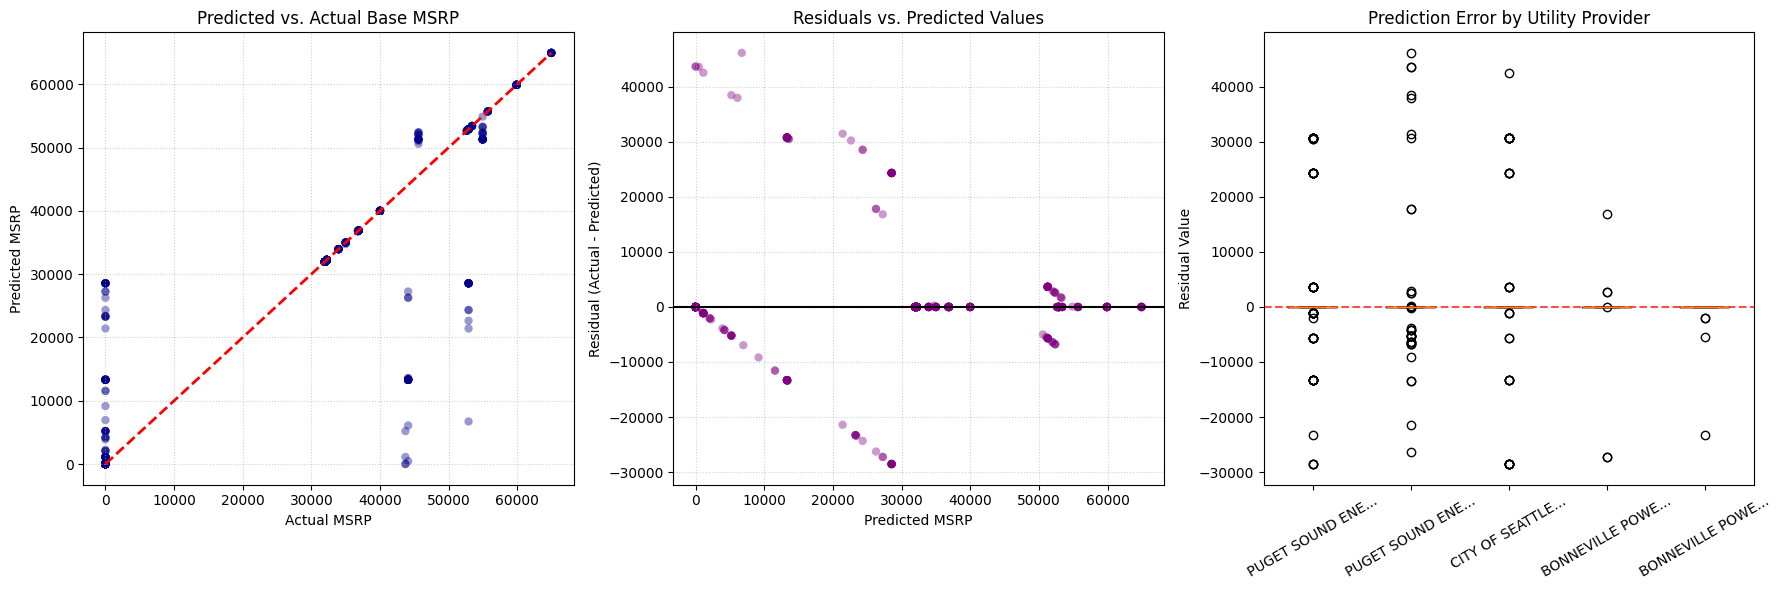

--- Random Forest Performance ---
RMSE: 1515.88
MAE:  89.30
R2:   0.9137


In [12]:
#QUESTION 4

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- 1. DATA WRANGLING & CLEANING ---
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

# Defining variables
target = 'Base MSRP'
num_features = ['Model Year', 'Electric Range']
cat_features = ['County', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Make']
# Electric Utility is NOT a predictor, but used for regional consistency check
eval_group = 'Electric Utility'

# Cleaning: Drop missing values in target and predictors
df_clean = df.dropna(subset=[target] + num_features + cat_features + [eval_group]).copy()

# Filtering: Removing extreme outliers in MSRP and Range (99th percentile)
df_clean = df_clean[df_clean[target] < df_clean[target].quantile(0.99)]
df_clean = df_clean[df_clean['Electric Range'] < df_clean['Electric Range'].quantile(0.99)]

# --- 2. PREPROCESSING ---
X = df_clean[num_features + cat_features]
y = df_clean[target]

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ColumnTransformer for Z-score (numerical) and Dummy Encoding (categorical)
preprocessor = ColumnTransformer(transformers=[
    ('zscore', StandardScaler(), num_features),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

# --- 3. MODELING ---
# Baseline Linear Regression and flexible Random Forest Regressor
lr_model = Pipeline([('prep', preprocessor), ('reg', LinearRegression())])
rf_model = Pipeline([('prep', preprocessor), ('reg', RandomForestRegressor(n_estimators=100, random_state=42))])

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# --- 4. PREDICTION & RESIDUAL CALCULATION ---
# We will use the Random Forest for the residual analysis as it typically fits MSRP better
y_pred = rf_model.predict(X_test)
residuals = y_test - y_pred

# --- 5. VISUALIZATION (Pure Matplotlib) ---
plt.figure(figsize=(18, 6))

# Plot 1: Predicted vs. Actual (Accuracy Assessment)
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.4, color='darkblue', edgecolors='none')
# 45-degree reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.title('Predicted vs. Actual Base MSRP', fontsize=12)
plt.xlabel('Actual MSRP')
plt.ylabel('Predicted MSRP')
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Residual Plot (Error Variance Assessment)
plt.subplot(1, 3, 2)
plt.scatter(y_pred, residuals, alpha=0.4, color='purple', edgecolors='none')
plt.axhline(0, color='black', linestyle='-', lw=1.5)
plt.title('Residuals vs. Predicted Values', fontsize=12)
plt.xlabel('Predicted MSRP')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 3: Regional Consistency (Residuals by Electric Utility)
plt.subplot(1, 3, 3)
# Creating a subset of test data to group residuals by utility
test_results = X_test.copy()
test_results['Residuals'] = residuals
test_results['Utility'] = df_clean.loc[X_test.index, eval_group]

# Select top 5 utilities for visual clarity
top_utilities = test_results['Utility'].value_counts().nlargest(5).index
box_data = [test_results[test_results['Utility'] == u]['Residuals'] for u in top_utilities]

plt.boxplot(box_data, labels=[u[:15] + '...' for u in top_utilities]) # Truncate names
plt.xticks(rotation=30)
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.title('Prediction Error by Utility Provider', fontsize=12)
plt.ylabel('Residual Value')

plt.tight_layout()
plt.show()

# --- 6. PERFORMANCE SUMMARY ---
print(f"--- Random Forest Performance ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2:   {r2_score(y_test, y_pred):.4f}")
